In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing,load_breast_cancer

# 评价指标
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score,accuracy_score,precision_score,
    recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report
)   # precision精确率:判断为正的样本,里面是正的概率;recall召回率:真实的正样本里面,被模型找出来多少,F1_score:Precision和recall的调和平均

# 中文显示设置
plt.rcParams['font.sans-serif']=['SimHei','Arial Unicode MS']
plt.rcParams['axes.unicode_minus']=False

# 固定随机种子,保证结果可复现
RANDOM_STATE=42

### 一.回归任务

* 回归任务公共操作

In [3]:
# 加载加州房价数据集
reg_data=fetch_california_housing()
X_reg=pd.DataFrame(reg_data.data,columns=reg_data.feature_names) # 特征
y_reg=reg_data.target # 标签

# 数据集划分
# 训练集80%，测试集20%;固定随机种子,保证可复现
X_reg_train,X_reg_test,y_reg_train,y_reg_test=train_test_split(
    X_reg,y_reg,test_size=0.2,random_state=RANDOM_STATE
)

# 标准化
# 树模型(RF/XGB/LGBM/AdaBoost)不需要标准化,但线性回归需要
# 在训练集上fit,在测试集上transform,避免数据泄露
scaler=StandardScaler()
X_reg_train_scaled=scaler.fit_transform(X_reg_train)
X_reg_test_scaled=scaler.transform(X_reg_test)


* 了解基础数据

In [4]:
X_reg.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [5]:
y_reg[:3] #房价

array([4.526, 3.585, 3.521])

##### 1.线性回归

Ridge最优参数alpha:{'alpha': 0.1}
线性回归:MAE=0.5332,MSE=0.5559,R2=0.3376


C:\Users\11146\AppData\Local\Temp\ipykernel_36404\2805334150.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_reg_test,y=y_pred_lr,ax=ax1,palette='viridis',alpha=0.3)


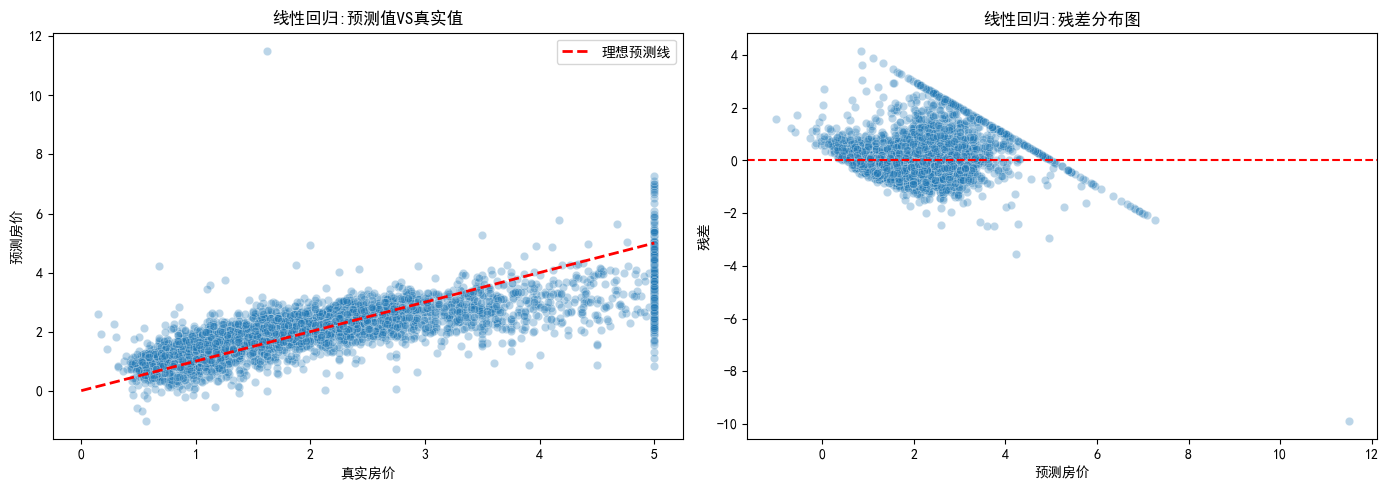

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge   #调参通过正则化实现

# 1.训练基础模型
lr=LinearRegression()   #采用OLS最小二乘法,不需要设置随机数种子
lr.fit(X_reg_train_scaled,y_reg_train)   # 线性回归必须要用标准化后的特征
y_pred_lr=lr.predict(X_reg_test_scaled)

# 2.调参方法
# 线性回归本身无超参数可调
# 实际工程中通过Ridge(L2正则化)/Lasso(L1正则化)来'调参'——调整正则强度alpha
ridge_params={'alpha':[0.001,0.01,0.1,1,10,100]}   # 候选正则强度
ridge_grid=GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_params,
    cv=5,   # 五折交叉验证
    scoring='neg_mean_squared_error',   # 负均方误差,因为GridSearchCV默认是最大化指标,所以取负号
    n_jobs=-1
)
ridge_grid.fit(X_reg_train_scaled,y_reg_train)
y_pred_ridge=ridge_grid.predict(X_reg_test_scaled)
print(f'Ridge最优参数alpha:{ridge_grid.best_params_}')
best_lr=ridge_grid.best_estimator_   # 获取最优模型
y_pred_lr=best_lr.predict(X_reg_test_scaled)   # 使用最优模型预测

# 3.评价指标
mae_lr=mean_absolute_error(y_pred_lr,y_reg_test)
mse_lr=mean_squared_error(y_pred_lr,y_reg_test)
r2_lr=r2_score(y_reg_test,y_pred_lr)
print(f'线性回归:MAE={mae_lr:.4f},MSE={mse_lr:.4f},R2={r2_lr:.4f}')

# 可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121)   # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122)   # 第二幅图:残差分布图(应近似随机分布)

# 第一幅图:预测值VS真实值散点图
sns.scatterplot(x=y_reg_test,y=y_pred_lr,ax=ax1,palette='viridis',alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('线性回归:预测值VS真实值')
ax1.legend()

# 第二幅图:残差分布图
resid=y_reg_test-y_pred_lr
sns.scatterplot(x=y_pred_lr,y=resid,alpha=0.3,ax=ax2)
ax2.axhline(y=0,color='r',ls='--')   # 残差为0的参考线
ax2.set_xlabel('预测房价')
ax2.set_ylabel('残差')
ax2.set_title('线性回归:残差分布图')

plt.tight_layout()

* 结论:标签房价和部分特征存在非线性关系难以拟合,同时存在异常值/极端值干扰模型

##### 2.随机森林

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RF最优参数:{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
随机森林:MAE=0.3205
随机森林:MSE=0.2406
随机森林:R²=0.7512


C:\Users\11146\AppData\Local\Temp\ipykernel_36404\2717263071.py:42: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_reg_test,y=y_pred_rf,ax=ax1,palette='husl',alpha=0.3)


<Axes: ylabel='None'>

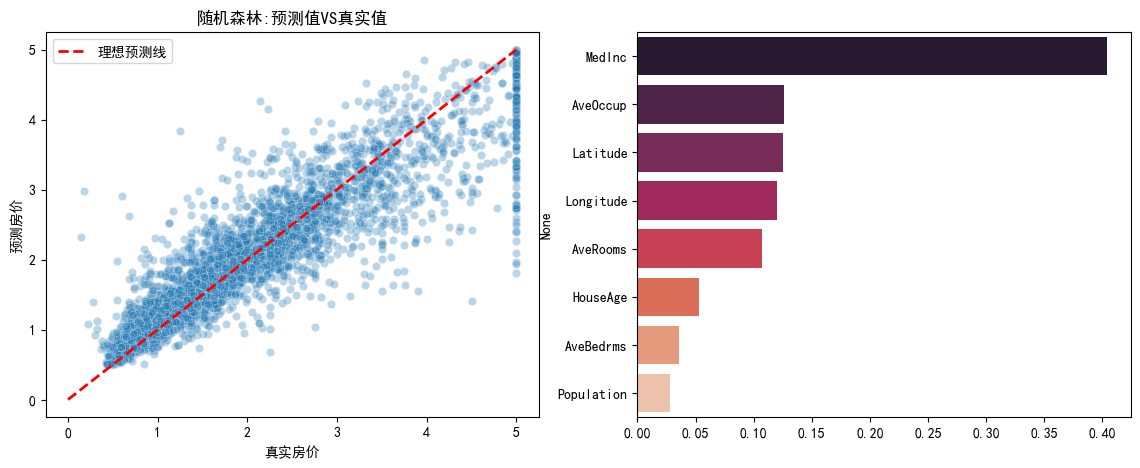

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1.训练基础模型(树模型不需要标准化,直接用原始特征)
rf_reg=RandomForestRegressor(n_estimators=100,n_jobs=-1,random_state=RANDOM_STATE)
rf_reg.fit(X_reg_train,y_reg_train)

# 2.调参方法(RandomizedSearchCV随机搜索)
# 关键超参数说明:①min_samples_split:节点分裂所需最小样本数 ②min_samples_leaf:叶子节点最小样本数 ③max_features:每棵树随机选择的特征数
rf_params={
    'n_estimators':[100,200,300,500],   # 树的数量
    'max_depth':[None,10,15,20],   # 树的最大深度
    'min_samples_split':[2,5,10],   # 节点分裂所需最小样本数
    'min_samples_leaf':[1,2,4],   # 叶子节点最小样本数(层优先)
    'max_features':['sqrt','log2']   # 每棵树随机选择的特征数
}
rf_search=RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1,random_state=RANDOM_STATE),
    rf_params,
    n_iter=20,   # 随机搜索20次
    cv=5,   # 五折交叉验证
    scoring='neg_mean_squared_error',   # 负均方误差
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2   # 打印两个关键信息
)
rf_search.fit(X_reg_train,y_reg_train)
print(f'RF最优参数:{rf_search.best_params_}')
best_rf=rf_search.best_estimator_
y_pred_rf=best_rf.predict(X_reg_test)

# 3.评价指标
print(f'随机森林:MAE={mean_absolute_error(y_pred_rf,y_reg_test):.4f}')
print(f'随机森林:MSE={mean_squared_error(y_pred_rf,y_reg_test):.4f}')
print(f'随机森林:R²={r2_score(y_reg_test,y_pred_rf):.4f}')

# 4.可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121)   # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122)   # 第二幅图:特征重要性条形图

# 第一幅图:预测值VS真实值散点图
sns.scatterplot(x=y_reg_test,y=y_pred_rf,ax=ax1,palette='husl',alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('随机森林:预测值VS真实值')
ax1.legend()

# 第二幅图:特征重要性条形图
importance=pd.Series(best_rf.feature_importances_,index=X_reg.columns).sort_values(ascending=False)
sns.barplot(x=importance.values,y=importance.index,hue=importance.index,ax=ax2,palette='rocket')

##### 3.XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGB最优参数:{'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
XGBoost:MAE=(array([0.523947  , 0.89055526, 5.163697  , ..., 4.979992  , 0.67531335,
       1.7720238 ], shape=(4128,), dtype=float32), array([0.477  , 0.458  , 5.00001, ..., 5.00001, 0.723  , 1.515  ],
      shape=(4128,)))
XGBoost:MSE=0.1931
XGBoost:R²=0.8213


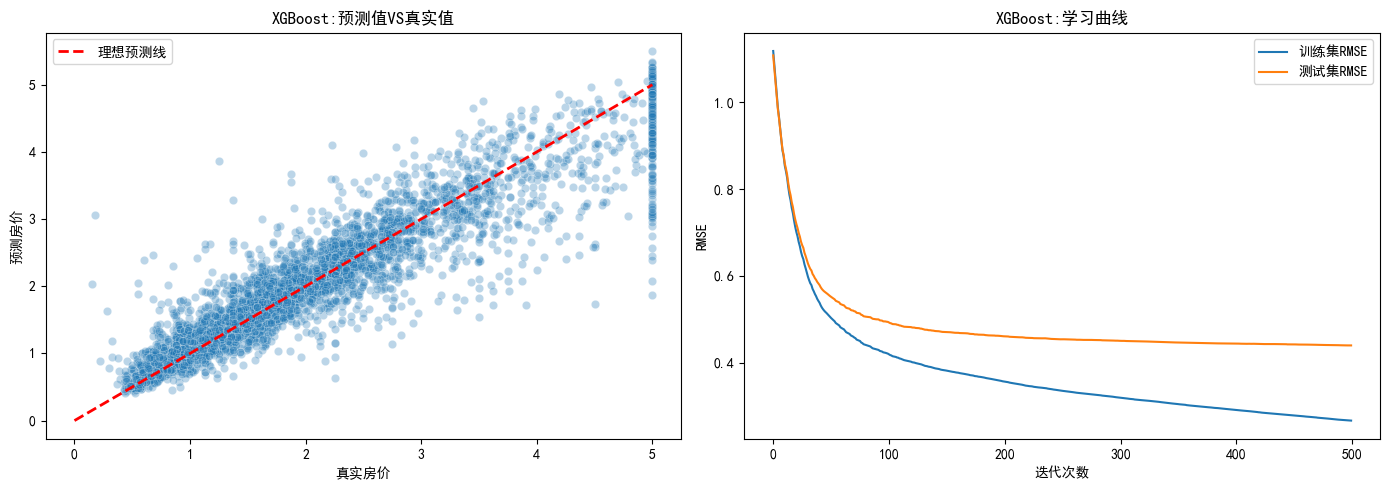

In [ ]:
from xgboost import XGBRegressor

# 1.训练基础模型
xgb_reg=XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,   # 单棵树深度
    subsample=0.8,   # 每棵树使用的样本比例
    colsample_bytree=0.8,   # 每棵树使用的特征比例
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_reg.fit(X_reg_train,y_reg_train)

# 2.调参方法
# 关键超参数:①reg_alpha->L1正则项 ②reg_lambda->L2正则项
xgb_params={
    'n_estimators':[100,300,500],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[3,5,7],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'reg_alpha':[0,0.1,1],
    'reg_lambda':[1,5,10]
}
xgb_search=RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE,n_jobs=-1),
    xgb_params,
    cv=5,
    n_iter=20,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_reg_train,y_reg_train)
print(f'XGB最优参数:{xgb_search.best_params_}')
best_xgb=xgb_search.best_estimator_
y_pred_xgb=best_xgb.predict(X_reg_test)

# 3.评价指标
print(f'XGBoost:MAE={y_pred_xgb,y_reg_test}')
print(f'XGBoost:MSE={mean_squared_error(y_pred_xgb,y_reg_test):.4f}')
print(f'XGBoost:R²={r2_score(y_reg_test,y_pred_xgb):.4f}')

# 4.可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121)   # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122)   # 第二幅图:学习曲线:训练过程中RMSE的变化(观察是否过拟合/欠拟合)

# 第一幅图:预测值VS真实值散点图
sns.scatterplot(x=y_reg_test,y=y_pred_xgb,ax=ax1,alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('XGBoost:预测值VS真实值')
ax1.legend()

# 第二幅图:学习曲线图
eval_set=[(X_reg_train, y_reg_train), (X_reg_test, y_reg_test)]
best_xgb.fit(X_reg_train,y_reg_train,eval_set=eval_set,verbose=False) # verbose=False表示不展示任何日志
ax2.plot(best_xgb.evals_result()['validation_0']['rmse'],label='训练集RMSE')
ax2.plot(best_xgb.evals_result()['validation_1']['rmse'],label='测试集RMSE')
ax2.set_xlabel('迭代次数')
ax2.set_ylabel('RMSE')
ax2.set_title('XGBoost:学习曲线')
ax2.legend()
plt.tight_layout()

##### 4.LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
LGBM最优参数:{'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 127, 'min_child_samples': 5, 'learning_rate': 0.1, 'estimators': 500, 'colsample_bytree': 0.7}
LightGBM:MAE=(array([0.56245953, 0.92455664, 4.88423656, ..., 4.99756581, 0.75384114,
       1.74605805], shape=(4128,)), array([0.477  , 0.458  , 5.00001, ..., 5.00001, 0.723  , 1.515  ],
      shape=(4128,)))
LightGBM:MSE=0.1945
LightGBM:R²=0.8210


<Axes: ylabel='None'>

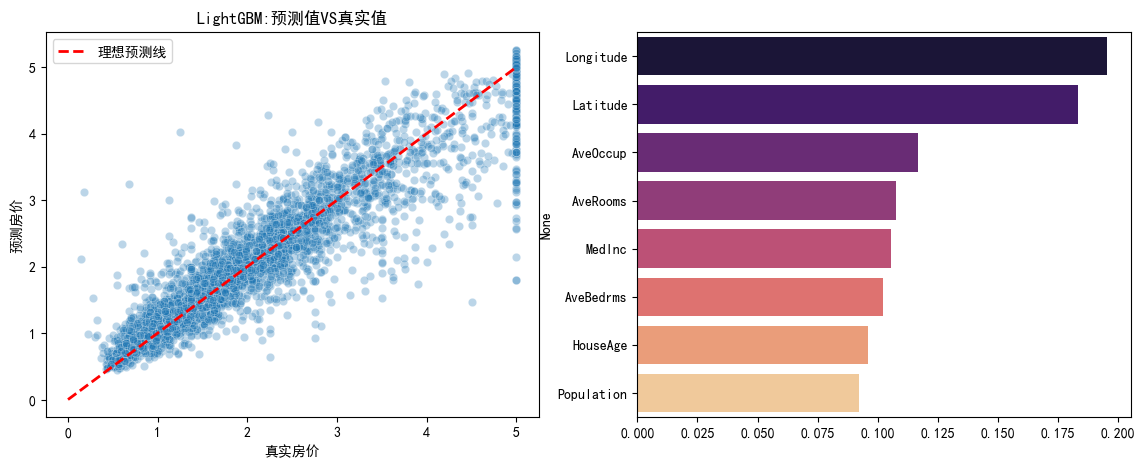

In [ ]:
from lightgbm import LGBMRegressor

# 1.训练基础模型
lgbm_reg=LGBMRegressor(
    n_estimators=100,
    learing_rate=0.1,
    num_leaves=31,   # LightGBM特有:叶子树(代替深度控制复杂度),即每棵树最多能有的叶子节点个数
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1   # verbose=-1表示关闭日志
    )
lgbm_reg.fit(X_reg_train,y_reg_train)
y_pred_lgbm=lgbm_reg.predict(X_reg_test)

# 2.调参方法
# 核心参数:①num_leaves ②min_child_samples:叶子最小样本数(逐叶子分裂)(如果传入权重weight,它统计的是权重之和,不是样本计数),其余与XGBoost类似
lgbm_params={
    'estimators':[100,300,500],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'num_leaves':[15,31,63,127],
    'min_child_samples':[5,10,20,50],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1],
    'reg_alpha':[0,0.1,1],
    'reg_lambda':[0,1,10]
}
lgbm_search=RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE,n_jobs=-1,verbose=-1),
    lgbm_params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
lgbm_search.fit(X_reg_train,y_reg_train)
print(f'LGBM最优参数:{lgbm_search.best_params_}')
best_lgbm=lgbm_search.best_estimator_
y_pred_lgbm=best_lgbm.predict(X_reg_test)

# 3.评价指标
print(f'LightGBM:MAE={y_pred_lgbm,y_reg_test}')
print(f'LightGBM:MSE={mean_squared_error(y_pred_lgbm,y_reg_test):.4f}')
print(f'LightGBM:R²={r2_score(y_reg_test,y_pred_lgbm):.4f}')

# 4.可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121) # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122) # 第二幅图:特征重要性排序图

# 第一幅图
sns.scatterplot(x=y_reg_test,y=y_pred_lgbm,ax=ax1,alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('LightGBM:预测值VS真实值')
ax1.legend()

# 第二幅图
importance=pd.Series(best_lgbm.feature_importances_,index=X_reg.columns)
importance = importance / importance.sum()
importance = importance.sort_values(ascending=False)
sns.barplot(x=importance.values,y=importance.index,hue=importance.index,ax=ax2,palette='magma')

##### 5.AdaBoost(自适应提升)

AdaBoost 最优参数: {'estimator': DecisionTreeRegressor(max_depth=5), 'learning_rate': 0.1, 'n_estimators': 100}
[AdaBoost] MAE=0.5105 | RMSE=0.6553 | R²=0.6723


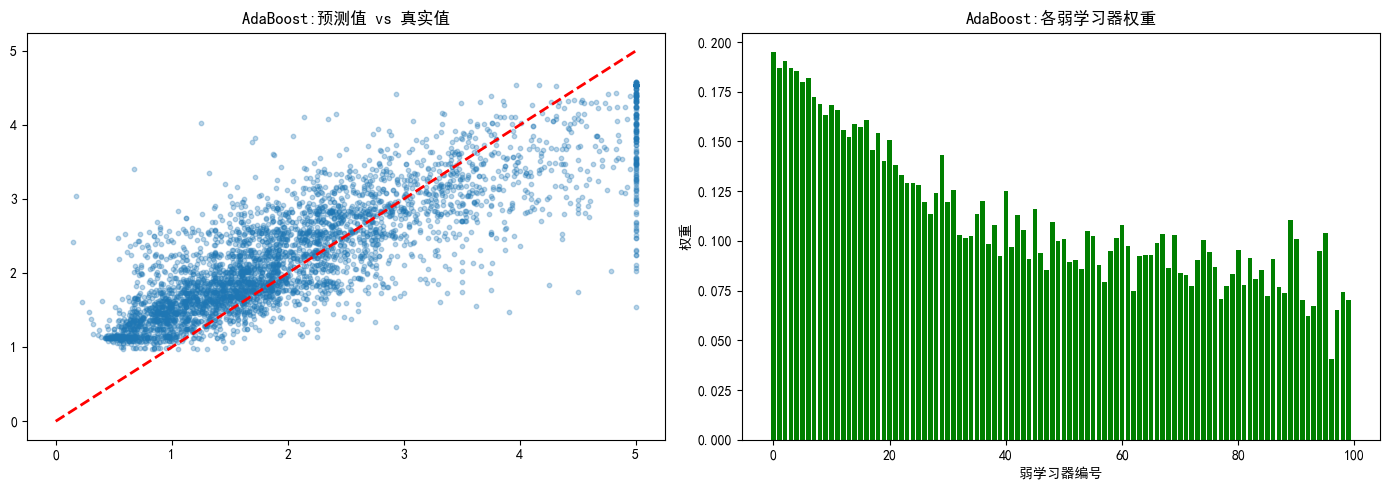

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

# 1.训练基础模型
ada_reg=AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.5,
    random_state=RANDOM_STATE
    )
ada_reg.fit(X_reg_train,y_reg_train)

# 2.调参方法
# AdaBoost调参重点:①n_estimators与learning_rate(二者需联动,学习率小则需要更多轮数) ②base_estimator(弱学习器):默认深度为1的树桩,可换更深的树
from sklearn.tree import DecisionTreeRegressor
ada_params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator': [
        DecisionTreeRegressor(max_depth=1),   # 树桩（默认）
        DecisionTreeRegressor(max_depth=3),   # 稍深的树
        DecisionTreeRegressor(max_depth=5)
    ]
}
ada_grid = GridSearchCV(
    AdaBoostRegressor(random_state=RANDOM_STATE),
    ada_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
ada_grid.fit(X_reg_train, y_reg_train)
print("AdaBoost 最优参数:", ada_grid.best_params_)
best_ada = ada_grid.best_estimator_
y_pred_ada = best_ada.predict(X_reg_test)

# 3.评价指标
print(f"[AdaBoost] MAE={mean_absolute_error(y_reg_test, y_pred_ada):.4f} | "
      f"RMSE={np.sqrt(mean_squared_error(y_reg_test, y_pred_ada)):.4f} | "
      f"R²={r2_score(,y_pred_ada,y_reg_test):.4f}")

# 4.可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_reg_test, y_pred_ada, alpha=0.3, s=10)
axes[0].plot([0, 5], [0, 5], 'r--', lw=2)
axes[0].set_title('AdaBoost:预测值 vs 真实值')

# 各弱学习器的权重分布
axes[1].bar(range(len(best_ada.estimator_weights_)), best_ada.estimator_weights_, color='green')
axes[1].set_xlabel('弱学习器编号'); axes[1].set_ylabel('权重')
axes[1].set_title('AdaBoost:各弱学习器权重')
plt.tight_layout(); plt.show()

##### 6.回归任务:模型横向对比

In [14]:
# 回归模型汇总对比
reg_results = pd.DataFrame({
    '模型': ['线性回归', '随机森林', 'XGBoost', 'LightGBM', 'AdaBoost'],
    'MAE':  [mean_absolute_error(y_reg_test, y_pred_lr),
             mean_absolute_error(y_reg_test, y_pred_rf),
             mean_absolute_error(y_reg_test, y_pred_xgb),
             mean_absolute_error(y_reg_test, y_pred_lgbm),
             mean_absolute_error(y_reg_test, y_pred_ada)],
    'RMSE': [np.sqrt(mean_squared_error(y_reg_test, p)) for p in
             [y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_lgbm, y_pred_ada]],
    'R²':   [r2_score(y_reg_test, p) for p in
             [y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_lgbm, y_pred_ada]]
})
reg_results

,模型,MAE,RMSE,R²
0,线性回归,0.533199,0.745579,0.575791
1,随机森林,0.320469,0.490475,0.816419
2,XGBoost,0.286792,0.439481,0.852608
3,LightGBM,0.286619,0.441012,0.851579
4,AdaBoost,0.510545,0.655345,0.672257


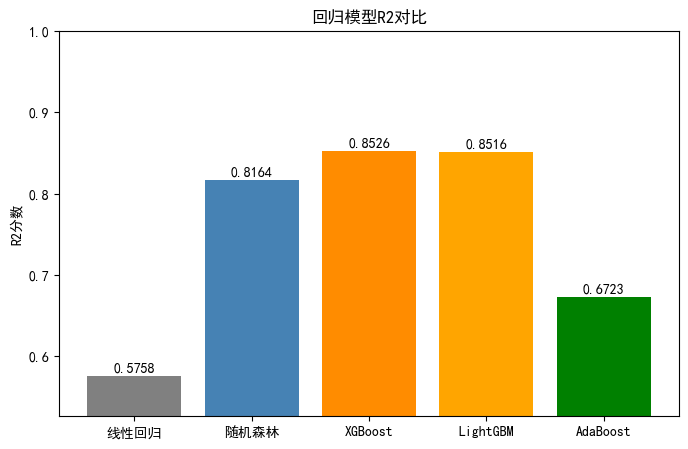

In [15]:
# 柱状图对比 R²
plt.figure(figsize=(8, 5))
plt.bar(reg_results['模型'], reg_results['R²'],
        color=['gray', 'steelblue', 'darkorange', 'orange', 'green'])
plt.ylabel('R2分数'); plt.title('回归模型R2对比')
plt.ylim(min(reg_results['R²']) - 0.05, 1.0)
for i, v in enumerate(reg_results['R²']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.show()